In [1]:
# !pip install aiomoex
# !pip install tinkoff-investments
# !pip install yfinance

In [2]:
# !pip install git+https://github.com/tinkoff/invest-python.git --no-deps
# !pip install tensorflow==2.15.0 scikit-learn matplotlib pandas
# !pip install cachetools deprecation python-dateutil
# Устанавливаем конкретную версию cachetools, которую просит Тинькофф
# !pip install "cachetools>=5.2.0,<6.0.0"
# !pip install dotenv
# !pip install fastparquet

# !pip uninstall -y pandas pyarrow
# !pip install "pandas>=2.0.0" "pyarrow>=11.0.0"
# !pip install seaborn

In [3]:
# !pip freeze > requirements.txt

In [4]:
from tinkoff.invest import Client, AsyncClient, CandleInterval, SecurityTradingStatus, InstrumentStatus
from tinkoff.invest.services import InstrumentsService
from tinkoff.invest.utils import quotation_to_decimal, now
from tinkoff.invest.caching.instruments_cache.instruments_cache import InstrumentsCache

import pyarrow
import pandas as pd
from pandas.tseries.offsets import DateOffset
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import os
import math

import time
from datetime import datetime, timezone, timedelta

from pathlib import Path
from typing import Optional

from dotenv import load_dotenv

import warnings
warnings.filterwarnings("ignore")

In [5]:
pd.set_option('display.max_columns', None) 
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', 1000)

In [6]:
DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)

In [7]:
load_dotenv()

TOKEN = os.getenv("TOKEN")

Словарь настроек интервалов: (Константа API, Максимальный шаг скачивания)

In [8]:
INTERVALS = {
    "5min":  (CandleInterval.CANDLE_INTERVAL_5_MIN, timedelta(days=7)),
    "15min": (CandleInterval.CANDLE_INTERVAL_15_MIN, timedelta(days=21)),
    "1hour": (CandleInterval.CANDLE_INTERVAL_HOUR, timedelta(days=31)),
    "4hour": (CandleInterval.CANDLE_INTERVAL_4_HOUR, timedelta(days=31 * 2)),
    "1day":  (CandleInterval.CANDLE_INTERVAL_DAY, timedelta(days=365))
}

Подробная информация по тикеру.

**Не работает с индексами вроде индекса МосБиржи**

In [9]:
def get_info(ticker, TOKEN = TOKEN):
    with Client(TOKEN) as client:
        instruments: InstrumentsService = client.instruments
        tickers = []
        for method in ["shares", "bonds", "etfs", "currencies", "futures"]:
            for item in getattr(instruments, method)().instruments:
                tickers.append(
                    {
                        "name": item.name,
                        "ticker": item.ticker,
                        "class_code": item.class_code,
                        "figi": item.figi,
                        "uid": item.uid,
                        "type": method,
                        "min_price_increment": quotation_to_decimal(
                            item.min_price_increment
                        ),
                        "scale": 9 - len(str(item.min_price_increment.nano)) + 1,
                        "lot": item.lot,
                        "trading_status": str(
                            SecurityTradingStatus(item.trading_status).name
                        ),
                        "api_trade_available_flag": item.api_trade_available_flag,
                        "currency": item.currency,
                        "exchange": item.exchange,
                        "buy_available_flag": item.buy_available_flag,
                        "sell_available_flag": item.sell_available_flag,
                        "short_enabled_flag": item.short_enabled_flag,
                        "klong": quotation_to_decimal(item.klong),
                        "kshort": quotation_to_decimal(item.kshort),
                    }
                )

        tickers_df = pd.DataFrame(tickers)

        ticker_df = tickers_df[tickers_df["ticker"] == ticker]
        if ticker_df.empty:
            print("There is no such ticker: %s", ticker)
            # return

        figi = ticker_df["figi"].iloc[0]
        print(f"\nTicker {ticker} have figi={figi}\n")
        print(f"Additional info for this {ticker} ticker:")
        print(ticker_df.iloc[0])

        return figi

# ticker = "SBER"
# get_info(ticker)

Получить только FIGI.

In [10]:
def get_figi(ticker: str) -> str:
    ticker = ticker.upper()
    with Client(TOKEN) as client:
        response = client.instruments.find_instrument(query=ticker)
        
        # 1. Сначала ищем идеальный вариант: совпадение тикера + доступность для торгов
        for instrument in response.instruments:
            if instrument.ticker == ticker and instrument.api_trade_available_flag:
                # Маленький лайфхак: для акций РФ основной режим торгов - TQBR (акции) или SPBFUT (фьючерсы)
                if instrument.class_code in ['TQBR', 'TQCB', 'SPBFUT', 'CETS', 'TQTF']:
                    print(f"Подтверждено: {ticker} ({instrument.name}), FIGI: {instrument.figi}")
                    return instrument.figi
        
        # 2. Если идеальный не нашли, берем любой доступный с точным тикером
        for instrument in response.instruments:
            if instrument.ticker == ticker and instrument.api_trade_available_flag:
                return instrument.figi
                
        raise ValueError(f"Не удалось найти активный торговый инструмент для тикера {ticker}")

In [11]:
def get_5min(ticker: str) -> pd.DataFrame:
    ticker = ticker.upper()
    file_path = DATA_DIR / f"{ticker}_5min.parquet"

    # Если файл есть — читаем и сразу делаем DateTime колонкой
    if file_path.exists():
        print(f"Загружаю из кэша: {ticker}")
        df = pd.read_parquet(file_path)
        if df.index.name == "DateTime":
            df = df.reset_index()
        return df.sort_values("DateTime", ascending=False)

    # Если файла нет — скачиваем
    print(f"Скачиваю {ticker} с 01.01.2025...")
    figi = get_figi(ticker)
    new_rows = []
    current = datetime(2025, 1, 1)
    now = datetime.now()

    with Client(TOKEN) as client:
        while current < now:
            end = min(current + timedelta(days=7), now - timedelta(minutes=10))

            if end <= current:
                break

            for _ in range(3):
                try:
                    candles = client.market_data.get_candles(
                        figi=figi,
                        from_=current,
                        to=end,
                        interval=CandleInterval.CANDLE_INTERVAL_5_MIN
                    ).candles

                    for c in candles:
                        new_rows.append({
                            "DateTime": c.time,
                            "Open":  c.open.units  + c.open.nano  / 1e9,
                            "High":  c.high.units  + c.high.nano  / 1e9,
                            "Low":   c.low.units   + c.low.nano   / 1e9,
                            "Close": c.close.units + c.close.nano / 1e9,
                            "Volume": c.volume
                        })
                    print(f"  +{len(candles)} свечей → {end.strftime('%Y-%m-%d %H:%M')}")
                    break
                except Exception as e:
                    if "RESOURCE_EXHAUSTED" in str(e):
                        print("Лимит! Жду 45 сек...")
                        time.sleep(45)
                    else:
                        time.sleep(5)
            else:
                print(f"Не удалось скачать кусок {current.date()} → {end.date()}")
            
            current = end
            time.sleep(1.2)

    if not new_rows:
        raise RuntimeError(f"Не удалось скачать данные для {ticker}")

    df = pd.DataFrame(new_rows)
    df = df.sort_values("DateTime", ascending=False)
    
    df.to_parquet(file_path, compression="zstd", index=False)
    print(f"Сохранено: {file_path} → {len(df):,} строк")

    return df

In [12]:
def get_candles_data(ticker: str, 
                     interval_name: str = "5min",
                     start_date: datetime = datetime(2025, 1, 1), 
                     end_date: Optional[datetime] = None,
                     update_cache: bool = True) -> pd.DataFrame:
    """
    Загружает исторические свечи с кэшированием в Parquet.
    """
    ticker = ticker.upper()
    if interval_name not in INTERVALS:
        raise ValueError(f"Доступные интервалы: {list(INTERVALS.keys())}")
    
    t_interval, chunk_step = INTERVALS[interval_name]
    file_path = DATA_DIR / f"{ticker}_{interval_name}.parquet"
    
    # 1. Нормализация дат (naive)
    start_date = start_date.replace(tzinfo=None)
    end_date = (end_date or datetime.now()).replace(tzinfo=None)

    df = pd.DataFrame()

    # 2. Чтение кэша
    if file_path.exists():
        df = pd.read_parquet(file_path)
        df['DateTime'] = pd.to_datetime(df['DateTime']).dt.tz_localize(None)
        
        if not df.empty:
            cache_min = df['DateTime'].min()
            cache_max = df['DateTime'].max()
            
            # Если всё есть или обновление запрещено
            if (cache_min <= start_date and cache_max >= (end_date - timedelta(minutes=1))) or not update_cache:
                print(f"[{ticker}] Использую кэш (период: {cache_min.date()} - {cache_max.date()})")
                mask = (df['DateTime'] >= start_date) & (df['DateTime'] <= end_date)
                return df.loc[mask].sort_values("DateTime", ascending=False)

    if not update_cache:
        raise FileNotFoundError(f"Кэш для {ticker} пуст, а обновление отключено.")

    # 3. Определение диапазона докачки
    # Если в кэше уже что-то есть, качаем от последней свечи кэша до end_date
    download_start = start_date
    if not df.empty and df['DateTime'].max() > start_date:
        download_start = df['DateTime'].max()
    
    print(f"[{ticker}] Загрузка из API с {download_start} по {end_date}...")
    
    figi = get_figi(ticker)
    new_rows = []
    
    current_from = download_start.replace(tzinfo=timezone.utc)
    target_to = end_date.replace(tzinfo=timezone.utc)
    
    with Client(TOKEN) as client:
        while current_from < target_to:
            current_to = min(current_from + chunk_step, target_to)
            
            for attempt in range(3):
                try:
                    candles = client.market_data.get_candles(
                        figi=figi,
                        from_=current_from,
                        to=current_to,
                        interval=t_interval
                    ).candles

                    for c in candles:
                        new_rows.append({
                            "DateTime": c.time,
                            "Open":  c.open.units  + c.open.nano  / 1e9,
                            "High":  c.high.units  + c.high.nano  / 1e9,
                            "Low":   c.low.units   + c.low.nano   / 1e9,
                            "Close": c.close.units + c.close.nano / 1e9,
                            "Volume": c.volume
                        })
                    break 
                except Exception as e:
                    if "RESOURCE_EXHAUSTED" in str(e):
                        time.sleep(60)
                    else:
                        time.sleep(2)
            
            current_from = current_to
            time.sleep(0.2)

    # 4. Слияние и сохранение
    if new_rows:
        new_df = pd.DataFrame(new_rows)
        new_df['DateTime'] = pd.to_datetime(new_df['DateTime']).dt.tz_localize(None)
        df = pd.concat([df, new_df]).drop_duplicates(subset=['DateTime'])
    
    if df.empty:
        raise RuntimeError(f"Данные для {ticker} не получены")

    df = df.sort_values("DateTime", ascending=False)
    DATA_DIR.mkdir(parents=True, exist_ok=True)
    df.to_parquet(file_path, compression="zstd", index=False)
    
    mask = (df['DateTime'] >= start_date) & (df['DateTime'] <= end_date)
    return df.loc[mask]

In [13]:
def clean_market_data(df: pd.DataFrame) -> pd.DataFrame:
    """
    Очищает данные от пропусков и нулевых значений.
    """
    df = df.copy()
    
    # 1. Заменяем чистые нули на NaN (в цене Close/Open нулей быть не может)
    # Делаем это только для колонок с ценами
    cols_to_fix = ['Open', 'High', 'Low', 'Close']
    for col in cols_to_fix:
        df[col] = df[col].replace(0, pd.NA)
    
    # 2. Сортируем по времени (важно для правильного заполнения "вперед")
    df = df.sort_values("DateTime")
    
    # 3. Forward Fill: заполняем пропуски последним известным значением
    df[cols_to_fix] = df[cols_to_fix].ffill()
    
    # 4. Backward Fill: на случай, если пропуски в самых первых строках
    df[cols_to_fix] = df[cols_to_fix].bfill()
    
    # 5. Обработка объема (Volume)
    # Для объема пропуски лучше заменять на 0, так как сделок просто не было
    df['Volume'] = df['Volume'].fillna(0)
    
    return df

In [14]:
def prepare_daily_data(df: pd.DataFrame) -> pd.DataFrame:
    """
    Превращает любые данные (минуты, часы) в чистые дневные бары для стратегий.
    """
    df = df.copy()
    if not isinstance(df.index, pd.DatetimeIndex):
        df['DateTime'] = pd.to_datetime(df['DateTime'])
        df = df.set_index('DateTime')
    
    # Агрегируем: Open - первый в дне, Close - последний, Volume - сумма
    df_daily = df.resample('D').agg({
        'Open': 'first',
        'High': 'max',
        'Low': 'min',
        'Close': 'last',
        'Volume': 'sum'
    })
    
    # Заполняем выходные и праздники (биржи закрыты, цена не менялась)
    df_daily[['Open', 'High', 'Low', 'Close']] = df_daily[['Open', 'High', 'Low', 'Close']].ffill()
    df_daily['Volume'] = df_daily['Volume'].fillna(0)
    
    return df_daily.sort_index()

In [15]:
def fill_time_gaps(df: pd.DataFrame, interval_name: str = "5min") -> pd.DataFrame:
    """
    Вставляет пропущенные временные интервалы (строки), которых нет в данных.
    """
    # Маппинг для метода resample
    resample_map = {
        "5min": "5min", "15min": "15min", "1hour": "h", "1day": "D"
    }
    freq = resample_map.get(interval_name, "5min")
    
    df = df.set_index("DateTime").sort_index()
    
    # Создаем полный индекс без дыр от начала до конца
    full_range = pd.date_range(start=df.index.min(), end=df.index.max(), freq=freq)
    
    # Переиндексируем (появятся строки с NaN там, где были дыры)
    df = df.reindex(full_range)
    df.index.name = "DateTime"
    
    # Заполняем пустоты
    df[['Open', 'High', 'Low', 'Close']] = df[['Open', 'High', 'Low', 'Close']].ffill()
    df['Volume'] = df['Volume'].fillna(0)
    
    return df.reset_index()

In [18]:
# df = 
get_candles_data("LKOH", start_date=datetime(2015, 1, 1), end_date=datetime(2025, 12, 31))
# df_SBER = fill_time_gaps(df_SBER)
# df_SBER = clean_market_data(df_SBER)

[LKOH] Загрузка из API с 2015-01-01 00:00:00 по 2025-12-31 00:00:00...
Подтверждено: LKOH (ЛУКОЙЛ), FIGI: BBG004731032


,DateTime,Open,High,Low,Close,Volume
358786,2025-12-30 23:55:00,5912.5,5912.5,5908.5,5908.5,6
358785,2025-12-30 23:50:00,5912.5,5913.0,5912.5,5912.5,18
358784,2025-12-30 23:45:00,5912.5,5912.5,5912.5,5912.5,1
358783,2025-12-30 23:40:00,5913.0,5913.0,5913.0,5913.0,8
358782,2025-12-30 23:35:00,5913.0,5913.0,5913.0,5913.0,1
...,...,...,...,...,...,...
4,2018-03-07 18:50:00,3696.5,3699.0,3694.5,3696.0,1381
3,2018-03-07 18:45:00,3697.5,3697.5,3695.5,3695.5,1554
2,2018-03-07 18:40:00,3696.0,3702.0,3695.5,3696.0,2487
1,2018-03-07 18:35:00,3702.0,3703.5,3696.0,3696.5,3705


In [ ]:
# def get_all_moex_tickers():
#     """Получает список всех FIGI и тикеров, торгуемых на MOEX (акции и фонды)"""
#     with Client(TOKEN) as client:
#         # Используем корректный статус: INSTRUMENT_STATUS_BASE
#         # Если это не сработает, попробуйте вообще убрать аргумент, 
#         # так как по умолчанию возвращаются базовые инструменты.
#         status = InstrumentStatus.INSTRUMENT_STATUS_BASE
        
#         shares = client.instruments.shares(instrument_status=status).instruments
#         etfs = client.instruments.etfs(instrument_status=status).instruments
        
#         all_instruments = shares + etfs
        
#         moex_instruments = [
#             {
#                 'ticker': inst.ticker,
#                 'figi': inst.figi,
#                 'name': inst.name
#             }
#             for inst in all_instruments 
#             # Фильтруем именно Московскую биржу и проверяем доступность
#             if (inst.exchange == 'MOEX' or inst.real_exchange.name == 'REAL_EXCHANGE_MOEX') 
#             and inst.buy_available_flag 
#             and inst.api_trade_available_flag
#         ]
        
#         return moex_instruments

# # --- ОСНОВНОЙ ЦИКЛ ЗАПУСКА ---
# moex_list = get_all_moex_tickers()
# # print(f"Найдено инструментов на MOEX: {len(moex_list)}")
# # print(moex_list)

[{'ticker': 'VSMO', 'figi': 'BBG004S68CV8', 'name': 'ВСМПО-АВИСМА'}, {'ticker': 'UNAC', 'figi': 'BBG000Q7ZZY2', 'name': 'Объединенная авиастроительная корпорация'}, {'ticker': 'CNRU', 'figi': 'TCS00A10ANA1', 'name': 'Циан'}, {'ticker': 'VKCO', 'figi': 'TCS00A106YF0', 'name': 'ВК'}, {'ticker': 'MGNT', 'figi': 'BBG004RVFCY3', 'name': 'Магнит'}, {'ticker': 'KZIZ', 'figi': 'TCS009124010', 'name': 'Красногорский завод им. С.А. Зверева - ао'}, {'ticker': 'KZOSP', 'figi': 'BBG0029SG1C1', 'name': 'Казаньоргсинтез - акции привилегированные'}, {'ticker': 'WUSH', 'figi': 'TCS00A105EX7', 'name': 'Whoosh'}, {'ticker': 'UGLD', 'figi': 'TCS00A0JPP37', 'name': 'Южуралзолото ГК'}, {'ticker': 'LNZL', 'figi': 'BBG000SK7JS5', 'name': 'Лензолото'}, {'ticker': 'SELG', 'figi': 'BBG002458LF8', 'name': 'Селигдар'}, {'ticker': 'SLAV', 'figi': 'TCS009086904', 'name': 'Славнефть'}, {'ticker': 'PRFN', 'figi': 'TCS00A0JNXF9', 'name': 'ЧЗПСН-Профнастил'}, {'ticker': 'CARM', 'figi': 'TCS00A105NV2', 'name': 'КарМани'}

In [ ]:
# strategy_results = []

# print(f"Начинаю обработку {len(moex_list)} тикеров...")

# for item in moex_list:
#     ticker = item['ticker']
#     name = item['name']
    
#     print(f"\n>>> {ticker} ({name})")
    
#     try:
#         # Загружаем данные (используем 1day для стратегий на годы)
#         df = get_candles_data(
#             ticker=ticker, 
#             interval_name="1day",
#             start_date=datetime(2021, 1, 1)
#         )
        
#         if df.empty or len(df) < 10: # Проверка на "пустые" или новые листинги
#             print(f"Недостаточно данных для {ticker}")
#             continue

#         # Подготовка данных (предполагаем, что функция prepare_daily_data у вас есть)
#         clean_df = prepare_daily_data(df)

#         # Расчет Стратегии №1: Sell in May
#         ret_may, _, _ = benchmark_sell_in_may(
#             clean_df, start_cap, start_year=2021, end_year=2025
#         )
        
#         # Расчет Стратегии №2: DCA
#         ret_dca, _, _ = benchmark_dca(
#             clean_df, start_cap, start_year=2021, end_year=2025
#         )

#         # Сохраняем результат в список
#         strategy_results.append({
#             "Ticker": ticker,
#             "Name": name,
#             "Sell_in_May_Ret_%": round(ret_may, 2),
#             "DCA_Ret_%": round(ret_dca, 2)
#         })
        
#         print(f"Готово. May: {ret_may:.1f}%, DCA: {ret_dca:.1f}%")

#     except Exception as e:
#         print(f"Ошибка при обработке {ticker}: {e}")
#         continue

Начинаю обработку 206 тикеров...

>>> VSMO (ВСМПО-АВИСМА)
[VSMO] Кэш неполный. Докачиваю недостающее...
Подтверждено: VSMO (ВСМПО-АВИСМА), FIGI: BBG004S68CV8
Готово. May: 0.0%, DCA: -12.2%

>>> UNAC (Объединенная авиастроительная корпорация)
[UNAC] Кэш неполный. Докачиваю недостающее...
Подтверждено: UNAC (Объединенная авиастроительная корпорация), FIGI: BBG000Q7ZZY2
Готово. May: 16.5%, DCA: -26.5%

>>> CNRU (Циан)
[CNRU] Кэш неполный. Докачиваю недостающее...
Подтверждено: CNRU (Циан), FIGI: TCS00A10ANA1
Готово. May: 37.9%, DCA: 14.2%

>>> VKCO (ВК)
[VKCO] Кэш неполный. Докачиваю недостающее...
Подтверждено: VKCO (ВК), FIGI: TCS00A106YF0
Готово. May: 15.4%, DCA: -35.1%

>>> MGNT (Магнит)
[MGNT] Кэш неполный. Докачиваю недостающее...
Подтверждено: MGNT (Магнит), FIGI: BBG004RVFCY3
Готово. May: 0.0%, DCA: -37.9%

>>> KZIZ (Красногорский завод им. С.А. Зверева - ао)
[KZIZ] Кэш неполный. Докачиваю недостающее...
Готово. May: 172.2%, DCA: -22.2%

>>> KZOSP (Казаньоргсинтез - акции привилег

In [ ]:
# # 2. Создание DataFrame из списка результатов
# results_df = pd.DataFrame(strategy_results)

In [ ]:
# # 3. Сортировка по убыванию доходности второй стратегии (DCA)
# if not results_df.empty:
#     results_df = results_df.sort_values(by="DCA_Ret_%", ascending=False)
#     print("ИТОГОВАЯ ТАБЛИЦА (TOP 30 по DCA):")
#     print(results_df.head(30))
    
#     # Сохранение в CSV/Excel (опционально)
#     # results_df.to_excel("strategy_comparison.xlsx", index=False)
# else:
#     print("Результаты не найдены.")

ИТОГОВАЯ ТАБЛИЦА (TOP 30 по DCA):
      Ticker                                         Name  Sell_in_May_Ret_%  DCA_Ret_%
47      MRKV                                Россети Волга              45.35     206.28
153     GTRK                                          ГТМ              57.08     189.48
107     PMSB                               Пермэнергосбыт             184.86     149.20
138    PMSBP     Пермэнергосбыт - акции привилегированные             170.56     145.99
60      BSPB                         Банк Санкт-Петербург             116.50     145.91
64      KROT                              Красный Октябрь             458.80     135.03
109     RBCM                                          РБК             368.81     128.72
148     MRKC                                Россети Центр              47.09     119.00
143     MDMG                                  Мать и дитя              70.67     118.90
145     LENT                                        Лента             113.85     117.1

In [ ]:
# # 3. Сортировка по убыванию доходности второй стратегии (DCA)
# if not results_df.empty:
#     results_df = results_df.sort_values(by="Sell_in_May_Ret_%", ascending=False)
#     print("ИТОГОВАЯ ТАБЛИЦА (TOP 30 по Sell in May):")
#     print(results_df.head(30))
    
#     # Сохранение в CSV/Excel (опционально)
#     # results_df.to_excel("strategy_comparison.xlsx", index=False)
# else:
#     print("Результаты не найдены.")

ИТОГОВАЯ ТАБЛИЦА (TOP 30 по Sell in May):
      Ticker                                       Name  Sell_in_May_Ret_%  DCA_Ret_%
133     NTZL                                      НИТЕЛ            1027.98     -36.16
64      KROT                            Красный Октябрь             458.80     135.03
109     RBCM                                        РБК             368.81     128.72
132  VEON-RX                                       VEON             297.80      62.75
156     FESH                                       ДВМП             256.65      53.09
6      KZOSP  Казаньоргсинтез - акции привилегированные             237.39     -23.91
20      GRNT         Городские Инновационные Технологии             236.13     -18.65
107     PMSB                             Пермэнергосбыт             184.86     149.20
113     BLNG                                      Белон             176.58      -8.50
39     TGKBP            ТГК-2 - акции привилегированные             175.43       6.26
5       KZIZ

Бенчмарк инфляции: 51.25%
Бенчмарк вклада: 70.08%


,Ticker,Name,Sell_in_May_Ret_%,DCA_Ret_%,Beats_Inflation,Beats_Bank,Real_Ret_%,Beats_Inflation_DCA,Beats_Bank_DCA,Beats_Inflation_SIM,Beats_Bank_SIM,Real_Ret_DCA%,Real_Ret_SIM%
133,NTZL,НИТЕЛ,1027.98,-36.16,False,False,-87.411864,False,False,True,True,-87.411864,976.728136
64,KROT,Красный Октябрь,458.80,135.03,True,True,83.778136,True,True,True,True,83.778136,407.548136
109,RBCM,РБК,368.81,128.72,True,True,77.468136,True,True,True,True,77.468136,317.558136
132,VEON-RX,VEON,297.80,62.75,True,False,11.498136,True,False,True,True,11.498136,246.548136
156,FESH,ДВМП,256.65,53.09,True,False,1.838136,True,False,True,True,1.838136,205.398136



СРЕДНЯЯ ДОХОДНОСТЬ (DCA): 6.24%
МЕДИАННАЯ ДОХОДНОСТЬ (DCA): -4.04%
ОБОГНАЛИ ИНФЛЯЦИЮ (DCA): 27 из 206
СРЕДНЯЯ ДОХОДНОСТЬ (SIM): 39.37%
МЕДИАННАЯ ДОХОДНОСТЬ (SIM): 16.50%
ОБОГНАЛИ ИНФЛЯЦИЮ (SIM): 53 из 206


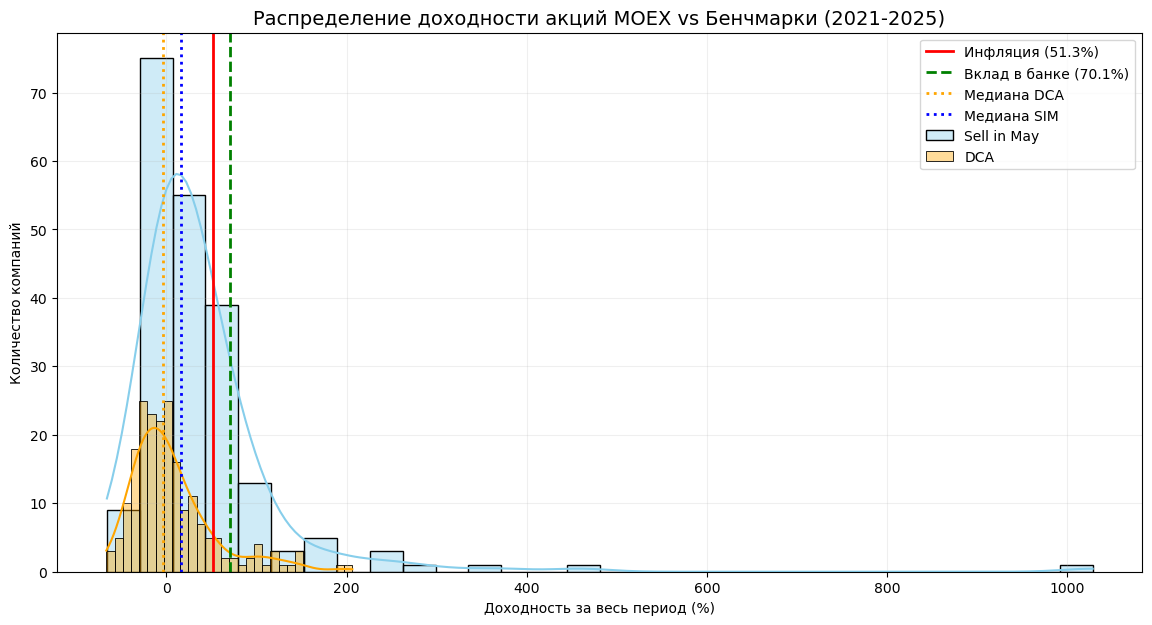

In [ ]:
# # 1. Убеждаемся, что переменные бенчмарков рассчитаны
# df_period = df_market[df_market.index >= 2021]
# total_inflation_pct = ((df_period['Inflation'] + 1).prod() - 1) * 100
# total_bank_pct = ((df_period['BankRate'] + 1).prod() - 1) * 100

# # 2. Добавляем новые колонки в готовый results_df
# results_df['Beats_Inflation_DCA'] = results_df['DCA_Ret_%'] > total_inflation_pct
# results_df['Beats_Bank_DCA'] = results_df['DCA_Ret_%'] > total_bank_pct
# results_df['Beats_Inflation_SIM'] = results_df['Sell_in_May_Ret_%'] > total_inflation_pct
# results_df['Beats_Bank_SIM'] = results_df['Sell_in_May_Ret_%'] > total_bank_pct

# # 3. Можно также добавить колонку с "Чистой доходностью" (доходность минус инфляция)
# results_df['Real_Ret_DCA%'] = results_df['DCA_Ret_%'] - total_inflation_pct
# results_df['Real_Ret_SIM%'] = results_df['Sell_in_May_Ret_%'] - total_inflation_pct

# # Проверяем результат
# print(f"Бенчмарк инфляции: {total_inflation_pct:.2f}%")
# print(f"Бенчмарк вклада: {total_bank_pct:.2f}%")
# display(results_df.head())

# print("\n" + "="*50)
# print(f"СРЕДНЯЯ ДОХОДНОСТЬ (DCA): {results_df['DCA_Ret_%'].mean():.2f}%")
# print(f"МЕДИАННАЯ ДОХОДНОСТЬ (DCA): {results_df['DCA_Ret_%'].median():.2f}%")
# print(f"ОБОГНАЛИ ИНФЛЯЦИЮ (DCA): {results_df['Beats_Inflation_DCA'].sum()} из {len(results_df)}")
# print("="*50)
# print(f"СРЕДНЯЯ ДОХОДНОСТЬ (SIM): {results_df['Sell_in_May_Ret_%'].mean():.2f}%")
# print(f"МЕДИАННАЯ ДОХОДНОСТЬ (SIM): {results_df['Sell_in_May_Ret_%'].median():.2f}%")
# print(f"ОБОГНАЛИ ИНФЛЯЦИЮ (SIM): {results_df['Beats_Inflation_SIM'].sum()} из {len(results_df)}")
# print("="*50)

# # Построение графиков
# plt.figure(figsize=(14, 7))
# sns.histplot(results_df["Sell_in_May_Ret_%"], color="skyblue", label="Sell in May", kde=True, bins=30, alpha=0.4)
# sns.histplot(results_df["DCA_Ret_%"], color="orange", label="DCA", kde=True, bins=30, alpha=0.4)

# # Линии бенчмарков
# plt.axvline(total_inflation_pct, color='red', linestyle='-', linewidth=2, label=f'Инфляция ({total_inflation_pct:.1f}%)')
# plt.axvline(total_bank_pct, color='green', linestyle='--', linewidth=2, label=f'Вклад в банке ({total_bank_pct:.1f}%)')
# plt.axvline(results_df["DCA_Ret_%"].median(), color='orange', linestyle=':', linewidth=2, label='Медиана DCA')
# plt.axvline(results_df["Sell_in_May_Ret_%"].median(), color='blue', linestyle=':', linewidth=2, label='Медиана SIM')

# plt.title("Распределение доходности акций MOEX vs Бенчмарки (2021-2025)", fontsize=14)
# plt.xlabel("Доходность за весь период (%)")
# plt.ylabel("Количество компаний")
# plt.legend()
# plt.grid(alpha=0.2)
# plt.show()